# TFR / ERD-ERS — all subjects

Per-subject work lives in [`src/tfr_batch.py`](../src/tfr_batch.py), the across-subject figures in
[`src/tfr_group.py`](../src/tfr_group.py) and the statistics in
[`src/tfr_stats.py`](../src/tfr_stats.py); this notebook is only the driver.
Choosing which ICA components to remove is the one thing that needs a human, so the work is
split into stages and that decision is written to disk once per subject:

| stage | call | interactive? | writes |
|---|---|---|---|
| 1 | `prepare_subject(subject)` | yes, once per subject | `Cache/<subj>_*`, `Figures/<subj>/ICA/` |
| 2 | `record_exclusions(subject, [...])` | manual decision | `configs/ica_exclusions.json` |
| 3 | `run_tfr_batch()` | no, all subjects at once | `TFRs/*.h5`, `TFRs/tfr_run.json`, `Figures/<subj>/TFR/`, `Figures/<subj>/Contrasts/` |
| 4 | `run_tfr_group()` | no, whole cohort at once | `Figures/Group/` |
| 4b | `run_tfr_group()`, same call | no | `Figures/Group/TimeBins/`, `Figures/<subj>/TimeBins/` |
| 5 | `run_tfr_stats()` | no, whole cohort at once | `Figures/Group/Stats/` |

**All settings live in the Parameters cell below** — nothing under it needs editing.

Stages 1–4 are descriptive: they say what the cohort looks like. Stage 5 is inferential: it says
which of it survives a test. Read them in that order — a p-value on a map you have not looked at is
not worth much, and a map without a test is not a result.

Stage 3 reads the **cached** epochs, so the component indices you record always refer to exactly
the data ICA was fitted on. Re-running stage 3 is cheap and idempotent — rerun it after revising a
subject's exclusions. `Cache/` is rebuildable and gitignored; delete it whenever you like.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import warnings
warnings.filterwarnings('ignore')

# Qt backend: stage 1 needs clickable component topographies and a scrollable sources browser
import PyQt5
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'qt')

import numpy as np
from src.tfr_batch import *
from src.tfr_group import *
from src.tfr_stats import *

print('project root     :', project_paths().root)
print('subjects         :', list_subjects())
print('electrode groups :', list(ELECTRODE_GROUPS))

project root     : C:\Users\gilad\New Git 3rd arm bci\3rd_arm_MI
subjects         : ['AEH', 'AN', 'AV', 'BA', 'EA', 'EE', 'ID', 'IO', 'LD', 'MN', 'NS', 'NZ', 'SK', 'SM', 'SN', 'TM']
electrode groups : ['FP', 'AF', 'F', 'FC', 'C', 'CP', 'P', 'PO', 'O']


## Parameters — the only cell you need to edit

Three dicts, because they invalidate different things:

| dict | what it controls | changing it means |
|---|---|---|
| `PARAMS` | preprocessing, as `EEG_Preprocessing` consumes it | the epoch cache is rebuilt **and the recorded ICA components stop being valid** — that subject must be re-reviewed |
| `TFR` | the time-frequency estimation and the figures | only `TFRs/*.h5` and the figures are recomputed; the ICA review stands |
| `STATS` | the stage-5 statistical design | nothing upstream is touched — but see the warning below |

`check_tfr_params` and `check_stats_params` enforce that split and the rules that would otherwise
fail deep inside MNE or produce a quietly wrong figure — a baseline that crosses the cue, a band
outside the estimated range, an active window that overlaps the baseline, a misspelled key.
`describe_tfr_params` / `describe_stats_params` print the dicts back with `*` on anything that
departs from the library default, and derive the analysis window `T` and the spectral smoothing
that follow from `freqs` and `n_cycles`.

**`STATS` is a pre-registration, not a setting.** The other two dicts you tune until the pipeline
does what you want. This one you fix *before* looking at the result: every contrast in it costs
every other contrast power through the Holm correction, and a contrast added after seeing the maps
is a different test with an error rate nobody can compute. `run_tfr_stats` records the whole dict in
`tfr_stats_summary.json` so what was tested is recoverable later.

**`TFR_LABEL`.** `tfr.save(..., overwrite=True)` and every figure write are unconditional, so
re-running with different settings destroys the previous run — which is why `TFRs_morlet/` and
`TFRs_percent/` exist as hand-made copies. Set `TFR_LABEL` to a name and this run's outputs nest
under `TFRs/<label>/` and `Figures/<label>/` instead. Leaving it `None` reproduces the current flat
layout exactly. `Cache/` and `configs/ica_exclusions.json` stay shared either way — the ICA review
is per subject, not per TFR setting.

**`TFR['mode']` sets the scale every colour limit is on.** `'logratio'` is `log10(power / baseline)`
— symmetric in ratio, so a halving is −0.30 and a doubling +0.30 — while `'percent'` is a *fraction*
of baseline, where a halving is −0.5 and the floor is −1. Switching between them therefore means
re-choosing `TFR['vlim']`, not just the mode: a percent-scale limit reused on logratio spans several
octaves and renders every fixed-scale panel flat mid-colour. `check_tfr_params` cannot catch this —
it validates the mode name, but nothing ties `vlim` to it.

**`STATS_TFR_LABEL` is separate on purpose.** It picks which tree the *tests* read, independently of
which one you last rendered figures into, so the inference does not silently change when you switch
`TFR_LABEL`. It is set to `TFR_LABEL` here, i.e. test what this run produced; point it somewhere
else only deliberately. Two traps if you do: `None` is the *root* `TFRs/` tree, which still holds an
older 10-subject logratio run rather than anything current, and `run_tfr_stats` only warns when the
tested tree's **mode** differs from the notebook's — so a wrong tree in the *same* mode passes in
silence. Prefer a log tree for inference whichever you pick: power ratios are multiplicative and
right-skewed, and the log makes the per-subject differences much closer to symmetric, which is what
both the sign-flip null and the t-statistic want.

**Why the ICA components are pinned.** A component *index* only means something for the
decomposition it was picked from. Change a preprocessing param, rebuild, and ICA refits with a
different component ordering, so the recorded indices would still apply cleanly while removing the
wrong sources. `record_exclusions` now stamps a fingerprint of the params the review was made
against, and stage 3 refuses rather than applying a stale one. The `stale` column in
`review_status()` shows it ahead of time.

In [2]:
# ══ PARAMETERS ═══════════════════════════════════════════════════════════════════
ELECTRODE_GROUP_NAMES = 'F+AF+FP+PO+O+FC+C+CP+P'   # all 9 groups = the 64-ch montage
TFR_LABEL = 'percent'    # None -> TFRs/ and Figures/ exactly as today. A string nests both
                        # under it, so a sweep cannot overwrite the previous run.
                        # 'percent' is now the REPORTING tree and the one this run
                        # writes. TFRs/logratio/ is kept as the INFERENCE tree - stage 5
                        # reads it, see STATS_TFR_LABEL below - so the two coexist by
                        # design rather than by accident. Note the percent tree held stale
                        # files for AV, EA, EE and GS from an older preprocessing; this
                        # run overwrites them, which is why the whole cohort is rebuilt
                        # rather than only the subjects that were missing.

# ── PREPROCESSING ────────────────────────────────────────────────────────────────
#    Rebuilds the epoch cache AND voids every recorded ICA review.
PARAMS = default_params(electrode_group_names=ELECTRODE_GROUP_NAMES)
PARAMS['desired_events'] = ['MiddleHand', 'RightHand', 'LeftHand', 'FixatedRest']
PARAMS['PerformAvgRef']  = True     # average re-reference
PARAMS['AddRefChannel']  = False    # off here: the FC group above has no FCz to rebuild
PARAMS['CenterByClass']  = True     # per-class mean removal -> the TFRs are INDUCED power
PARAMS['PerformCsd']     = False    # CSD is applied after ICA instead, in stage 3
PARAMS['PerformAsr']     = False    # Artifact Subspace Reconstruction on the continuous
                                    # data, BEFORE ICA is fitted, so the large transients
                                    # cannot dominate the decomposition. Off = every
                                    # existing result and recorded review unchanged;
                                    # flipping it rebuilds the cache, so the ICA is
                                    # refitted and has to be re-reviewed
PARAMS['asr_cutoff']     = 20       # rejection threshold, SD of the clean calibration
                                    # data. Lower = more aggressive
PARAMS['asr_max_bad_chans'] = 0.1   # max bad-channel fraction a calibration window may have
PARAMS['asr_backend']    = 'asrpy'  # 'asrpy' (euclid only) or 'meegkit'. meegkit
                                    # must be 0.1.7: newer ones need pyriemann>=0.7,
                                    # and 0.12 needs numpy 2, which breaks mne 1.6.1
PARAMS['asr_method']     = 'euclid' # 'euclid', or 'riemann' (Blum et al. 2019) which
                                    # requires asr_backend='meegkit' - asrpy accepts
                                    # 'riemann' but silently runs euclid, so we reject it
PARAMS['asr_estimator']  = 'lwf'    # meegkit only. 'riemann' REQUIRES a regularising
                                    # estimator: the average reference makes the block
                                    # covariances singular and the riemannian mean needs
                                    # positive definite input ('scm' fails outright)
PARAMS['filter_method']  = 'fir'
PARAMS['LowPass']        = 1       # 1 Hz high-pass, which is what ICA needs
PARAMS['HighPass']       = None     # no low cut here; TFR['lowpass'] does it in stage 3
PARAMS['epoch_tmin']     = -4       # epoch crop, s relative to cue
PARAMS['epoch_tmax']     = 5
PARAMS['bad_electrodes'] = {}       # deliberately empty: ICA/ICLabel handles noisy
                                    # channels, and dropping per-subject bads would give
                                    # every subject a different montage and break stacking
#   The remaining default_params keys (n_components, filters_bands, classifier_window_*,
#   augmentation_params, windowed_prediction_params, n_components_fbcsp, pipeline_name)
#   belong to the classifier stack and reach nothing on this path. The readback below
#   lists them under 'unused here' so it is not a guess.

# ── TFR ──────────────────────────────────────────────────────────────────────────
#    Only recomputes TFRs/*.h5 and the figures. No cache rebuild, no re-review.
TFR = default_tfr_params()

TFR['freqs']          = np.arange(4, 35)   # 4-34 Hz
TFR['n_cycles']       = None               # None -> = freqs, so T = 1.0 s at every freq
TFR['time_bandwidth'] = 4.0                # smoothing bandwidth = time_bandwidth / T
TFR['decim']          = 10                 # 500 -> 50 Hz
TFR['lowpass']        = 40                 # applied to the epochs before the TFR
TFR['n_jobs']         = -1

TFR['mode']          = 'percent'           # (power - baseline) / baseline. A FRACTION,
                                           # not a %: -0.5 IS a 50% ERD, +1.0 a doubling.
                                           # Every limit below is on THIS scale. Chosen so
                                           # ERD% is what the pipeline stores rather than
                                           # something derived at figure time; it is an
                                           # exact bijection with 'logratio', so no number
                                           # changes, only which form is canonical.
                                           # NOT symmetric in ratio: a halving is -0.5 but
                                           # a doubling is +1.0, so a symmetric vlim clips
                                           # ERS before it clips ERD.
TFR['baseline']      = (-2, -0.5)          # inside fixation on every trial, with T/2 guard
TFR['active_window'] = (0.5, 3)          # what every topomap / band map averages over
TFR['bands']         = {'Mu': (8, 13), 'Beta': (13, 30)}

TFR['vlim']          = (-0.5, 0.5)    # the FIXED-scale figures: per-subject topo/bands,
                                      # the contrasts, and their group equivalents.
                                      # On this FRACTION scale +/-0.5 is -50% to +50%, so
                                      # a 50% ERD is exactly full scale. The earlier
                                      # percent run used +/-0.75; re-read the colorbars
                                      # after this run and widen if ERS is clipping.
                                      # Do NOT carry the log-era reading of this number
                                      # over - there +/-0.5 meant 0.32x to 3.2x.
TFR['autoscale_pct'] = 90             # the two AUTOSCALED figures (subject grid, grand-
                                      # average panel), which vlim does not reach. Each
                                      # still scales to its own band, but to this
                                      # percentile of |value| rather than the max, so the
                                      # extremes stop setting the scale. 100 = max =
                                      # nothing clips. The panel needs a LOW value to move
                                      # at all: averaging the cohort has already removed
                                      # the tail the grid still has. A percentile is
                                      # scale-free, so 90 carries over from the percent
                                      # run unchanged — but the limits it PRODUCES do not
                                      # (they were 0.33 grid / 0.18 panel on percent);
                                      # re-read them off the colorbars after this run.
TFR['cmap']       = 'RdBu_r'
TFR['figure_dpi'] = 150

#   The stage-4b binned grid: rows = conditions, columns = consecutive time bins, so the
#   ERD can be read as a time course instead of one active_window average. Its colorbar is
#   in PERCENT (100x this fraction scale), and vlim above does not reach it - it autoscales
#   through autoscale_pct like the other two group figures.
#
#   It is drawn TWICE per band, because averaging percent change across subjects can mean
#   two things and they differ by up to 85 percentage points on this cohort:
#     <band>_time_grid.png          arithmetic mean of the subjects' percent change
#     <band>_time_grid_geomean.png  geometric mean of the subjects' power ratios
#   Both share one colour scale, so the arithmetic mean's sensitivity to an extreme subject
#   is visible instead of assumed. Both are computed from the per-subject data via the
#   power ratio, so the pair is identical whichever tree it is run on.
TFR['time_grid_window']     = (0.0, 5.0)   # 0-5 s, the whole imagery period. The epochs
                                           # run to epoch_tmax = 5, so this sits exactly on
                                           # the boundary check_tfr_params enforces.
TFR['time_grid_step']       = 0.2          # -> 25 columns. NOT 25 independent samples:
                                           # n_cycles = freqs holds the analysis window at
                                           # T = 1.0 s, so neighbouring columns share ~80%
                                           # of their data. check_tfr_params prints this,
                                           # and the figure states it in its title.
TFR['time_grid_cols']       = 10           # columns per block -> three blocks, 0-2 s,
                                           # 2-4 s and a half-width 4-5 s. 25 does not
                                           # divide evenly; block edges are kept on whole
                                           # seconds rather than made equal width.
TFR['time_grid_per_subject'] = True        # also Figures/<subj>/TimeBins/, on the SAME
                                           # colour scale as the group figures

#   The same window again as a PLAYABLE animation - one topomap per condition sweeping
#   through 0-5 s, written as a self-contained .html with play / pause / step / scrub. It
#   needs no ffmpeg: matplotlib's HTMLWriter embeds each frame as a base64 PNG, which is
#   what makes the file portable and also what makes it ~10 MB. Group only, both means,
#   both bands -> 4 files; a per-subject set would be hundreds of MB for something nobody
#   watches, and the static grids already answer the per-subject question.
TFR['time_anim_enabled']    = True
TFR['time_anim_step']       = 0.1          # -> 50 frames. This is PLAYBACK SMOOTHNESS, not
                                           # resolution: it is far inside the 1.0 s analysis
                                           # window either way, so halving it interpolates a
                                           # smoother sweep over the same estimates rather
                                           # than resolving anything new.
TFR['time_anim_fps']        = 5            # 10 s to play the whole window
TFR['time_anim_dpi']        = 110          # the dial to turn if the .html files get too big

TFR['ica_n_components']       = None        # None -> len(ch_names) - 1
TFR['ica_decim']              = 3
TFR['ica_random_state']       = 97          # changing this reorders the components
TFR['ica_method']             = 'fastica'
TFR['iclabel_exclude_labels'] = ['eye blink', 'eye movement', 'muscle artifact']

# ── STATISTICS (stage 5) ─────────────────────────────────────────────────────────
#    Reads the TFRs and writes nothing upstream. PRE-SPECIFY THIS: a contrast added
#    after seeing the maps is a different test with a different error rate.
STATS_TFR_LABEL = 'logratio'  # which tree the TESTS run on. PINNED, and deliberately
                        # NOT TFR_LABEL: the reporting tree is now 'percent', but
                        # inference must stay on the log tree for the reason spelled
                        # out below. Following TFR_LABEL here would silently move
                        # stage 5 onto the percent tree.
                        # Point it elsewhere only deliberately — and note the guard in
                        # run_tfr_stats only warns when the MODES differ, so a wrong tree
                        # in the SAME mode (e.g. the older 10-subject logratio tree in
                        # TFRs/) passes silently. Prefer a log tree for inference either
                        # way: power ratios are multiplicative and right-skewed, and the
                        # log makes the per-subject differences much closer to symmetric,
                        # which is what both the sign-flip null and the t-statistic want.
STATS = default_stats_params()
STATS['active_window'] = TFR['active_window']   # keep the tested window and the plotted
STATS['bands']         = TFR['bands']           # bands identical to the figures'

# ── what to run ──────────────────────────────────────────────────────────────────
SUBJECT_NAME   = 'MN'    # stages 1-2, one subject at a time
FORCE          = False   # stage 1: ignore the cache and rebuild
SUBJECTS       = None    # stages 3-5: None = every reviewed subject
SAVE_H5        = True
SAVE_FIGS      = True
SAVE_CONTRASTS = True
RUN_CLUSTER    = True    # stage 5 tier 2; the expensive half. False = tier 1 only.

# ─────────────────────────────────────────────────────────────────────────────────
paths = project_paths(label=TFR_LABEL)
stats_paths = project_paths(label=STATS_TFR_LABEL)
check_tfr_params(PARAMS, TFR, label=TFR_LABEL, paths=paths)
check_stats_params(STATS, tfr_params=TFR)   # the cohort-dependent checks run in stage 5
describe_tfr_params(PARAMS, TFR)
describe_stats_params(STATS)

print(f"\ntfrs    : {paths.tfrs.relative_to(paths.root)}")
print(f"figures : {paths.figures.relative_to(paths.root)}")
print(f"cache   : {paths.cache.relative_to(paths.root)}  (shared across labels)")
print(f"stats   : {stats_paths.tfrs.relative_to(stats_paths.root)}  (tested tree)")
print()
review_status(paths=paths)

  !! time_grid_step = 0.2 s is shorter than the 1.00 s analysis window, so adjacent columns of the binned grid share ~80% of their data. It is a smoothed time course sampled every 0.2 s, not 5 independent samples per second.
PREPROCESSING - rebuilds the epoch cache AND voids the ICA review
  desired_events               ['MiddleHand', 'RightHand', 'LeftHand', 'FixatedRest']    conditions to compute a TFR for
  Electorde_Group              64 ch: F7, F5, F3 ... P8                                  channels kept; all 9 groups keeps every subject stackable
  PerformAvgRef                True                                                      average re-reference
  AddRefChannel                False                                                     reconstruct FCz; off here, so the FC group has no FCz
  CenterByClass                True                                                      per-class mean removal - this is what makes the TFRs INDUCED power
  PerformCsd                   F

[{'subject': 'AEH',
  'n_files': 3,
  'cached': True,
  'reviewed': True,
  'n_excluded': 24,
  'stale_review': None,
  'n_tfrs': 4,
  'note': ''},
 {'subject': 'AN',
  'n_files': 4,
  'cached': True,
  'reviewed': True,
  'n_excluded': 12,
  'stale_review': None,
  'n_tfrs': 4,
  'note': ''},
 {'subject': 'AV',
  'n_files': 6,
  'cached': True,
  'reviewed': True,
  'n_excluded': 33,
  'stale_review': True,
  'n_tfrs': 4,
  'note': ''},
 {'subject': 'BA',
  'n_files': 3,
  'cached': True,
  'reviewed': True,
  'n_excluded': 24,
  'stale_review': None,
  'n_tfrs': 4,
  'note': ''},
 {'subject': 'EA',
  'n_files': 4,
  'cached': True,
  'reviewed': True,
  'n_excluded': 38,
  'stale_review': None,
  'n_tfrs': 4,
  'note': ''},
 {'subject': 'EE',
  'n_files': 3,
  'cached': True,
  'reviewed': True,
  'n_excluded': 23,
  'stale_review': None,
  'n_tfrs': 4,
  'note': ''},
 {'subject': 'ID',
  'n_files': 3,
  'cached': True,
  'reviewed': True,
  'n_excluded': 19,
  'stale_review': None,


## Stage 1 — preprocess one subject and fit ICA

Set `SUBJECT_NAME` in the Parameters cell and run this one. It loads and preprocesses every
`<subject>_MI*.xdf` recording (montage, average reference, 1-100 Hz + 50 Hz notch, epochs -5 to 6 s
around the cue), concatenates them, fits ICA on the result and classifies the components with
ICLabel. Epochs + ICA are cached, so re-running is instant; set `FORCE = True` to rebuild from the
raw files.

All 64 channels are kept for every subject — no per-subject bad-electrode dropping — so the TFRs
stack across subjects for group analysis. Noisy channels are dealt with here, as ICA components.

Three windows open:

- **component topographies** — click one to open its properties (spectrum, epochs image)
- **sources browser** — trials are colour-coded by condition, with a marker at each cue
- **ICLabel summary** — the full 7-class probability per component; hatched = ICLabel's suggestion

Saved to `Figures/<subject>/ICA/` regardless of what you decide.

[AV] preprocessing 6 recording(s): AV_MI1.xdf, AV_MI2-2.xdf, AV_MI2.xdf, AV_MI3-2.xdf, AV_MI3-3.xdf, AV_MI3.xdf

--- AV_MI1.xdf ---
Creating RawArray with float64 data, n_channels=67, n_times=475496
    Range : 0 ... 475495 =      0.000 ...   950.990 secs
Ready.

###########################################################
removing subject specific bad electrodes from the raw data
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.

###########################################################
filtering the data
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper 

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s


Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 3301 samples (6.602 s)



[Parallel(n_jobs=1)]: Done  64 out of  64 | elapsed:    0.6s finished
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.1s


Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 2 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 2.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 1.00 Hz)
- Filter length: 825 samples (1.650 s)



...

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 2 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  64 out of  64 | elapsed:    0.1s finished


- Lower passband edge: 2.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 1.00 Hz)
- Filter length: 825 samples (1.650 s)

Used Annotations descriptions: ['FixatedRest', 'LeftHand', 'Long Break', 'MiddleHand', 'Rest', 'RightHand']

###########################################################
extracting event info: {'FixatedRest': 1, 'LeftHand': 2, 'Long Break': 3, 'MiddleHand': 4, 'Rest': 5, 'RightHand': 6}
Not setting metadata
10 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 10 events and 4001 original time points ...


[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  64 out of  64 | elapsed:    0.1s finished


0 bad epochs dropped
CenterByClass is off - leaving the per-class evoked response in the data.

###########################################################
removing bad channels from epochs:
Adding metadata with 1 columns

[AV] concatenating 6 file(s) of epochs...
Adding metadata with 1 columns
174 matching events found
No baseline correction applied
[AV] 174 epochs, 64 channels, counts: {'FixatedRest': 32, 'LeftHand': 45, 'MiddleHand': 48, 'RightHand': 49}
Creating RawArray with float64 data, n_channels=64, n_times=696174
    Range : 0 ... 696173 =      0.000 ...  1392.346 secs
Ready.
Fitting ICA (63 components, fastica, seed 97) on 1392 s of epoch data...
Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 63 components
Fitting ICA took 24.3s.
ICA fitted (63 components).
Running ICLabel classification...
[AV] caching epochs and ICA to Cache/ ...
Writing ICA solution to C:\Users\gilad\New Git 3rd arm bci\3rd_arm_MI\Cache\AV-ica.fif...


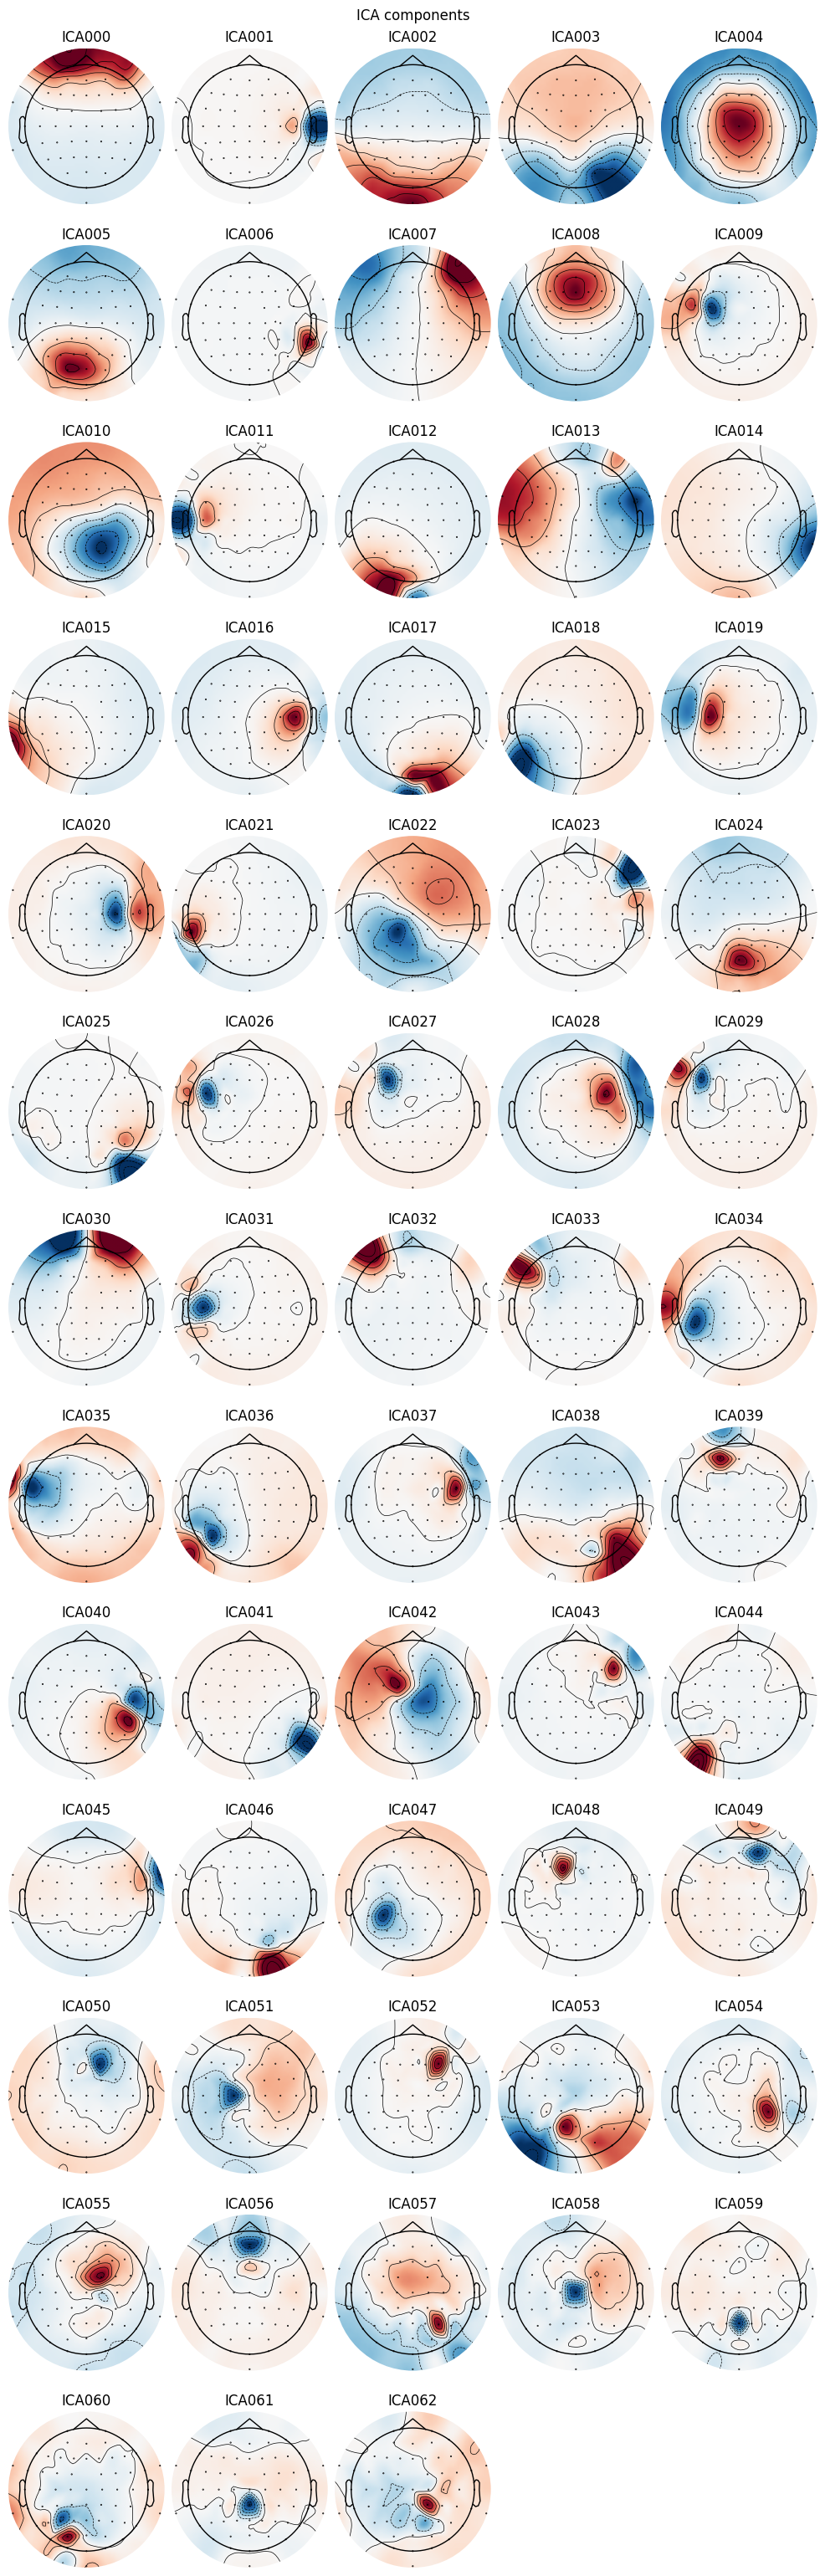

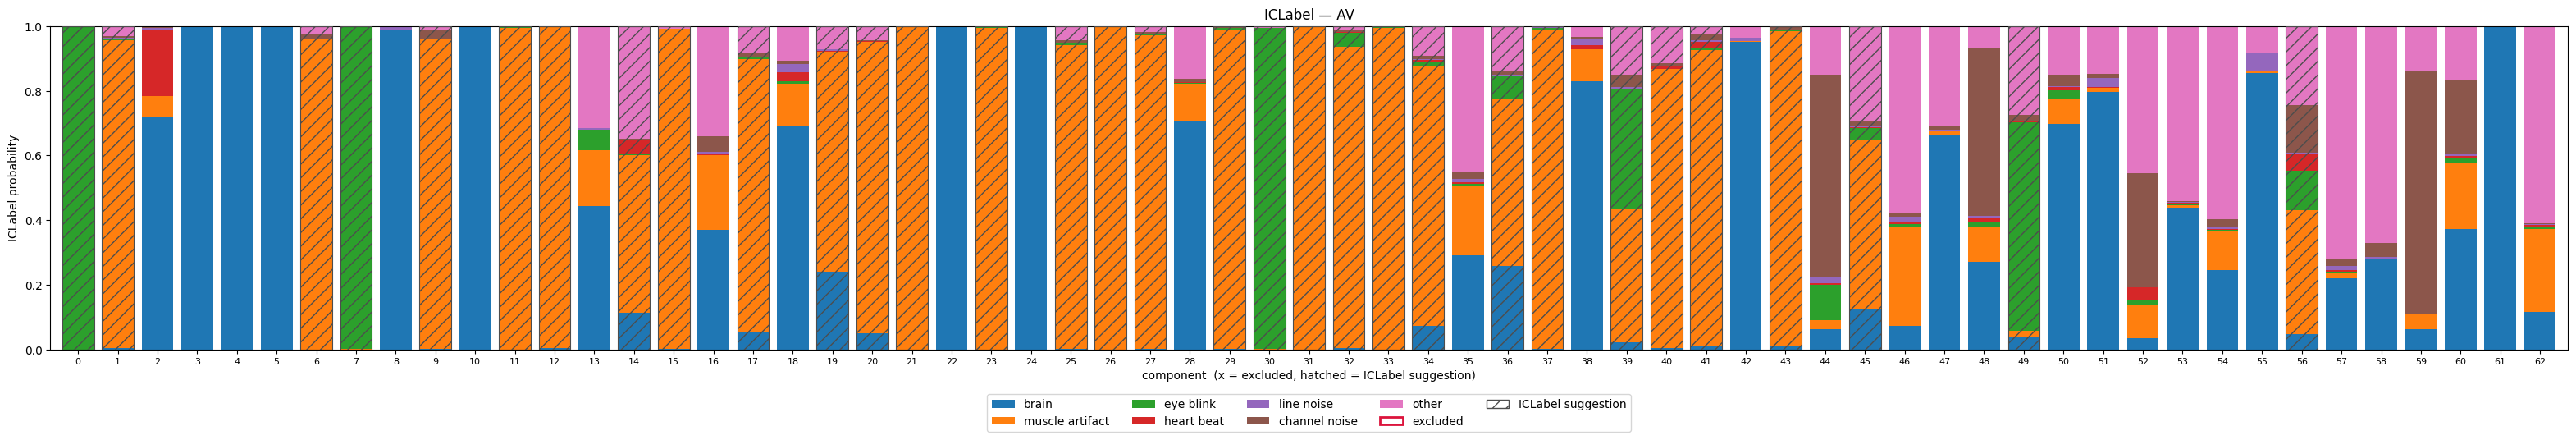


[AV] ICLabel suggests excluding: [0, 1, 6, 7, 9, 11, 12, 14, 15, 17, 19, 20, 21, 23, 25, 26, 27, 29, 30, 31, 32, 33, 34, 36, 37, 39, 40, 41, 43, 45, 49, 56]
[AV] already recorded: [0, 1, 2, 5, 8, 12, 13, 14, 16, 18, 20, 21, 23, 24, 25, 27, 28, 29, 30, 31, 32, 33, 35, 38, 39, 40, 41, 42, 43, 44, 50, 51, 57]  (no note, reviewed 2026-09-01)

Review the plots, then record your decision with e.g.:
    record_exclusions('AV', [0, 1, 6, 7, 9, 11, 12, 14, 15, 17, 19, 20, 21, 23, 25, 26, 27, 29, 30, 31, 32, 33, 34, 36, 37, 39, 40, 41, 43, 45, 49, 56], note='')


In [24]:
state = prepare_subject(SUBJECT_NAME, force=FORCE,
                        params_dict=PARAMS, tfr_params=TFR, paths=paths)

## Stage 2 — record which components to remove

`state['suggested']` is ICLabel's suggestion, and it is deliberately trigger-happy (on subject BA it
flagged 21 of 59 components where 7 were actually artifactual). Treat it as a shortlist: keep the
clear eye-blink / eye-movement / EMG components and anything with a physiologically implausible
topography, and leave borderline "muscle" components that carry real sensorimotor rhythm alone.

Edit the list below and run the cell. It merges into `configs/ica_exclusions.json`, so it is safe to
call again later to revise a subject — just rerun stage 3 for them afterwards.

The entry also records a fingerprint of the preprocessing params it was reviewed against. If you
later change `PARAMS` and rebuild, stage 3 will refuse to apply these indices rather than silently
removing the wrong components, and `review_status()` flags the subject in its `stale` column.

In [31]:
record_exclusions('MN', [0,2, 8, 22,27,30, 35, 36,37, 39, 43, 45, 48], note='')# Or paste an explicit list — state['suggested'] is only a shortlist:
# record_exclusions(SUBJECT_NAME, [0, 1, 2, 3, 7, 9, 10], note='blinks + left temporal EMG',
#                   paths=paths)

[MN] recorded 13 component(s) to remove: [0, 2, 8, 22, 27, 30, 35, 36, 37, 39, 43, 45, 48]


{'exclude': [0, 2, 8, 22, 27, 30, 35, 36, 37, 39, 43, 45, 48],
 'note': '',
 'reviewed': '2026-09-01',
 'params_fingerprint': '8ec1f1964e4e'}

Now go back to the Parameters cell, change `SUBJECT_NAME` to the next subject, and repeat stages
1–2. `review_status()` below shows who is still outstanding.

In [41]:
review_status(paths=paths)

TFR label: 'logratio'  ->  TFRs\logratio
subject   files  cached  reviewed  removed  stale  tfrs   note
AEH           3     yes       yes       24      ?     0   
AN            4     yes       yes       12      ?     0   
AV            6     yes       yes       33      -     0   
BA            3     yes       yes       24      ?     0   
EA            4     yes       yes       38      ?     0   
EE            3     yes       yes       23      ?     0   
GS            4     yes       yes       29      -     0   
ID            3     yes       yes       19      ?     0   
IO            3     yes       yes       32      -     0   
LD            3     yes       yes       23      ?     0   
MN            4     yes       yes       13      -     0   
NS            4     yes       yes       25      ?     0   
NZ            4     yes       yes       24      ?     0   
SK            5     yes       yes       35      -     0   
SM            4     yes       yes       28      -     0   
SN         

[{'subject': 'AEH',
  'n_files': 3,
  'cached': True,
  'reviewed': True,
  'n_excluded': 24,
  'stale_review': None,
  'n_tfrs': 0,
  'note': ''},
 {'subject': 'AN',
  'n_files': 4,
  'cached': True,
  'reviewed': True,
  'n_excluded': 12,
  'stale_review': None,
  'n_tfrs': 0,
  'note': ''},
 {'subject': 'AV',
  'n_files': 6,
  'cached': True,
  'reviewed': True,
  'n_excluded': 33,
  'stale_review': False,
  'n_tfrs': 0,
  'note': ''},
 {'subject': 'BA',
  'n_files': 3,
  'cached': True,
  'reviewed': True,
  'n_excluded': 24,
  'stale_review': None,
  'n_tfrs': 0,
  'note': ''},
 {'subject': 'EA',
  'n_files': 4,
  'cached': True,
  'reviewed': True,
  'n_excluded': 38,
  'stale_review': None,
  'n_tfrs': 0,
  'note': ''},
 {'subject': 'EE',
  'n_files': 3,
  'cached': True,
  'reviewed': True,
  'n_excluded': 23,
  'stale_review': None,
  'n_tfrs': 0,
  'note': ''},
 {'subject': 'GS',
  'n_files': 4,
  'cached': True,
  'reviewed': True,
  'n_excluded': 29,
  'stale_review': False

## Stage 3 — TFRs and figures for every reviewed subject

For each subject: apply the recorded ICA exclusions to the cached epochs, convert to CSD, low-pass
at `TFR['lowpass']`, then per condition compute a multitaper TFR over `TFR['freqs']` and baseline it
against `TFR['baseline']` in `TFR['mode']`. The Parameters cell prints the analysis window `T` and
the spectral smoothing those settings imply.

Per subject that writes:

- `TFRs/<subject>_<event>_tfr.h5` — one per condition, which stage 4 below aggregates
- `Figures/<subject>/TFR/` — `<event>_topo`, `<event>_joint`, `<event>_bands` per condition
- `Figures/<subject>/Contrasts/` — every pairwise condition difference
- `Figures/<subject>/ICA/iclabel_final.png` — the components that were actually removed

and once per batch, `TFRs/tfr_run.json` — both params dicts in full, the git commit, the library
versions and the per-subject exclusions, so a TFR can be traced back to what produced it.

Figures render on the `Agg` backend so a full run doesn't open ~180 Qt windows; the Qt backend is
restored when the batch finishes. A subject that fails is reported in the summary table and skipped
rather than aborting the run — rerun those via `SUBJECTS`.

In [22]:
SUBJECTS = ['AN', 'AV', 'BA', 'ID', 'LD',  'MN', 'NS', 'SM', 'SN', 'TM']

In [23]:
results = run_tfr_batch(SUBJECTS, save_h5=SAVE_H5, save_figs=SAVE_FIGS,
                        save_contrasts=SAVE_CONTRASTS,
                        params_dict=PARAMS, tfr_params=TFR, paths=paths)

rendering figures on 'Agg' (restoring 'module://matplotlib_inline.backend_inline' afterwards)

[1/10] AN
  note: [AN]'s ICA review predates params fingerprinting; assuming it still matches. Re-record it to pin it down.
  !! WARNING: AN's cache was built with different preprocessing parameters (filter_method, epoch_tmin, epoch_tmax). Rerun prepare_subject('AN', force=True).
Reading C:\Users\gilad\New Git 3rd arm bci\3rd_arm_MI\Cache\AN_pre_ica-epo.fif ...
    Found the data of interest:
        t =   -5000.00 ...    6000.00 ms
        0 CTF compensation matrices available
Adding metadata with 1 columns
220 matching events found
No baseline correction applied
0 projection items activated
Reading C:\Users\gilad\New Git 3rd arm bci\3rd_arm_MI\Cache\AN-ica.fif ...
Now restoring ICA solution ...
Ready.
[AN] removing 12 component(s): [2, 3, 7, 12, 21, 23, 24, 25, 29, 32, 33, 36]  (no note, reviewed 2026-08-04)
Applying ICA — removing components: [2, 3, 7, 12, 21, 23, 24, 25, 29, 32, 33, 36]
C

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 161 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 287 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    0.1s
[Parallel(n_jobs=1)]: Done 647 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 881 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 1151 tasks      | elapsed:    0.4s
[Parallel(n_jobs=1)]: Done 1457 tasks      | elapsed:    0.6s
[Parallel(n_jobs=1)]: Done 1799 tasks      | elapsed:    0.8s
[Parallel(n_jobs=1)]: Done 2177 tasks      | elapsed:    0.9s
[Parallel(n_jobs=1)]: Done 2591 tasks      | elapsed:    1.1s
[Parallel(n_jobs=1)]: Done 3041 tasks      | elapsed:    1.4s
[Parallel(n_jobs=1)]: Done 3527 tasks      | elapsed:    1.6s
[Parallel(n_jobs=1)]: Done 4049 tasks      | elapsed:    1.8s
[Parallel(n_jobs=1)]: Done 4607 tasks      | elapsed:    2.2s
[Parallel(n_job

  saved Figures\percent\AN\ICA\iclabel_final.png
[AN] computing TFR for MiddleHand (60 epochs)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    8.0s


Applying baseline correction (mode: percent)


...

  saved TFRs\percent\TM_LeftHand_tfr.h5
No baseline correction applied
  saved Figures\percent\TM\TFR\LeftHand_topo.png
No baseline correction applied
No baseline correction applied
No baseline correction applied
  saved Figures\percent\TM\TFR\LeftHand_joint.png
No baseline correction applied
No baseline correction applied
  saved Figures\percent\TM\TFR\LeftHand_bands.png
[TM] computing TFR for FixatedRest (30 epochs)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    0.5s


Applying baseline correction (mode: percent)


[Parallel(n_jobs=-1)]: Done  62 out of  64 | elapsed:    2.8s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done  64 out of  64 | elapsed:    2.8s finished


  saved TFRs\percent\TM_FixatedRest_tfr.h5
No baseline correction applied
  saved Figures\percent\TM\TFR\FixatedRest_topo.png
No baseline correction applied
No baseline correction applied
No baseline correction applied
  saved Figures\percent\TM\TFR\FixatedRest_joint.png
No baseline correction applied
No baseline correction applied
  saved Figures\percent\TM\TFR\FixatedRest_bands.png
No baseline correction applied
No baseline correction applied
No baseline correction applied
  saved Figures\percent\TM\Contrasts\MiddleHand_minus_RightHand_joint.png
No baseline correction applied
No baseline correction applied
No baseline correction applied
  saved Figures\percent\TM\Contrasts\MiddleHand_minus_LeftHand_joint.png
No baseline correction applied
No baseline correction applied
No baseline correction applied
  saved Figures\percent\TM\Contrasts\MiddleHand_minus_FixatedRest_joint.png
No baseline correction applied
No baseline correction applied
No baseline correction applied
  saved Figures\pe

## Stage 4 — aggregate figures across subjects

Everything here lives in [`src/tfr_group.py`](../src/tfr_group.py). It reads the
`TFRs/<subject>_<event>_tfr.h5` files written by stage 3 and writes to `Figures/Group/`:

- `Subjects/<band>_subject_grid.png` — **the headline**: rows = subjects, columns = conditions,
  with the grand average as a final `GROUP` row, all on one shared colour scale
- `GrandAverage/grand_average_panel.png` — compact summary, rows = bands, columns = conditions
- `GrandAverage/<event>_{topo,joint,bands}.png` — the same three views as the per-subject figures
- `Contrasts/<cond1>_minus_<cond2>_joint.png` — every pairwise difference
- `tfr_group_summary.json` — which subjects went in, on which grid, under the **whole** `TFR` dict

The cohort is whoever has been ICA-reviewed **and** has every condition on the current TFR grid,
so the figures grow on their own as more subjects come through stages 1–2. `group_status()` shows who
is in and why the others are out. Subjects are never silently dropped, and a subject sitting on a
different frequency / time / channel grid raises rather than being averaged in — `TFRs/` also holds
legacy files from an earlier pipeline (54 channels, 2-34 Hz, `decim=2`, `ClosePalm` labels) for
subjects that no longer have recordings at all.

Set `TFR_LABEL` in the Parameters cell to keep a run's figures instead of overwriting these.

Everything on this page is **descriptive**. Nothing here is a test, the colour scales are chosen to
make the maps readable rather than to mark significance, and no panel has been corrected for the
fact that there are 64 channels × 31 frequencies × 551 times in it. Stage 5 below does the testing.

In [24]:
# Group figures are static, so render them inline rather than in Qt windows
get_ipython().run_line_magic('matplotlib', 'inline')

group_status(paths=paths, events=PARAMS['desired_events'])

TFR label: 'percent'  ->  TFRs\percent
subject    reviewed  events               shape  admitted   why not
AEH             yes     4/4       (64, 31, 551)       yes   
AN              yes     4/4       (64, 31, 551)       yes   
AV              yes     4/4       (64, 31, 551)       yes   
BA              yes     4/4       (64, 31, 551)       yes   
EA              yes     4/4       (64, 31, 551)       yes   
EE              yes     4/4       (64, 31, 551)       yes   
ID              yes     4/4       (64, 31, 551)       yes   
IO              yes     4/4       (64, 31, 551)       yes   
LD              yes     4/4       (64, 31, 551)       yes   
MN              yes     4/4       (64, 31, 551)       yes   
NS              yes     4/4       (64, 31, 551)       yes   
NZ              yes     4/4       (64, 31, 551)       yes   
SK              yes     4/4       (64, 31, 551)       yes   
SM              yes     4/4       (64, 31, 551)       yes   
SN              yes     4/4       (64, 

[{'subject': 'AEH',
  'reviewed': True,
  'events': ['MiddleHand', 'RightHand', 'LeftHand', 'FixatedRest'],
  'n_events': 4,
  'shape': (64, 31, 551),
  'admitted': True,
  'reason': ''},
 {'subject': 'AN',
  'reviewed': True,
  'events': ['MiddleHand', 'RightHand', 'LeftHand', 'FixatedRest'],
  'n_events': 4,
  'shape': (64, 31, 551),
  'admitted': True,
  'reason': ''},
 {'subject': 'AV',
  'reviewed': True,
  'events': ['MiddleHand', 'RightHand', 'LeftHand', 'FixatedRest'],
  'n_events': 4,
  'shape': (64, 31, 551),
  'admitted': True,
  'reason': ''},
 {'subject': 'BA',
  'reviewed': True,
  'events': ['MiddleHand', 'RightHand', 'LeftHand', 'FixatedRest'],
  'n_events': 4,
  'shape': (64, 31, 551),
  'admitted': True,
  'reason': ''},
 {'subject': 'EA',
  'reviewed': True,
  'events': ['MiddleHand', 'RightHand', 'LeftHand', 'FixatedRest'],
  'n_events': 4,
  'shape': (64, 31, 551),
  'admitted': True,
  'reason': ''},
 {'subject': 'EE',
  'reviewed': True,
  'events': ['MiddleHand'

In [25]:
results = run_tfr_group(SUBJECTS, events=PARAMS['desired_events'],
                        save_figs=SAVE_FIGS, tfr_params=TFR, paths=paths)

group, grand = results['group'], results['grand']

cohort: N = 10  ['AN', 'AV', 'BA', 'ID', 'LD', 'MN', 'NS', 'SM', 'SN', 'TM']
  conditions : MiddleHand, RightHand, LeftHand, FixatedRest
  grid       : 64 ch x 31 freqs (4-34 Hz) x 551 times (-5.00..6.00 s)
rendering figures on 'Agg' (restoring 'module://matplotlib_inline.backend_inline' afterwards)

Mu subject grid
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied
No baseline correction applied


## Stage 4b — ERD over time, as a grid of topomaps

Stage 4 averages the whole `active_window` into one topomap per condition, which says *where* the
ERD is but not *when*. This lays the same maps out as a time course: rows = conditions, columns =
consecutive `time_grid_step` bins across `time_grid_window`, wrapped into stacked blocks with a time
axis under each.

Three things to know before reading it:

- **The scale is percent**, 100x the stored fraction: -50 on the colorbar is a halving of power,
  +100 a doubling. Everything is derived from the power ratio `P / P_base` rather than from the
  stored numbers, so the grid is identical whether the tree is `percent` or `logratio` - the two are
  an exact bijection and the figure must not depend on which one is canonical.
- **There are two group figures per band, and they are different quantities.** Averaging percent
  change across subjects can mean either:

  | file | mean | behaviour |
  |---|---|---|
  | `<band>_time_grid.png` | arithmetic, `mean(pct_s)` | the Pfurtscheller convention; what a `%` colorbar implies; sensitive to one extreme subject |
  | `<band>_time_grid_geomean.png` | geometric, `exp(mean(log r_s)) - 1` | damps extremes; how every other stage-4 figure averages |

  They differ by up to 85 percentage points here. Both are computed from the per-subject data (never
  from `grand`, whose meaning depends on the tree's mode) and share one colour scale, so the
  difference is visible rather than assumed.
- **The columns are not independent.** The analysis window is `n_cycles / freq` = 1.0 s wide, five
  times the 0.2 s bin, so adjacent columns are built from largely the same data. Read it as a
  smoothed time course, not as five measurements per second.

The subject figures share that same scale, so a subject can be read against the cohort.

**There is also a playable version of the same sweep.** `save_group_time_animations` writes one
self-contained `.html` per band per mean, with play / pause / step / scrub and a speed control:

| file | |
|---|---|
| `<band>_time_animation.html` | arithmetic mean |
| `<band>_time_animation_geomean.html` | geometric mean |

It needs no ffmpeg - matplotlib's `HTMLWriter` embeds every frame as a base64 PNG, so each file is
self-contained and around 10 MB. `time_anim_step` (0.1 s, 50 frames) is playback smoothness rather
than resolution: it sits far inside the 1.0 s analysis window, so a finer step interpolates the same
estimates more densely rather than resolving anything new. The animations share the static grids'
colour scale, so the two can be read against each other.

All of this runs as part of `run_tfr_group` above; the cells below re-render from the `group` already
in memory, which is quicker while iterating on the settings.


In [26]:
%matplotlib inline
save_group_time_grids(group, grand, group_figure_dir('TimeBins', paths),
                      paths=paths, tfr_params=TFR)

# One band, group only, while iterating - the full call above writes
# len(bands) * (1 + n_subjects) figures.
# fast = dict(TFR, bands={'Mu': TFR['bands']['Mu']}, time_grid_per_subject=False)
# save_group_time_grids(group, grand, group_figure_dir('TimeBins', paths),
#                       paths=paths, tfr_params=fast)


  saved Figures\percent\Group\TimeBins\Mu_time_grid.png
  saved Figures\percent\Group\TimeBins\Mu_time_grid_geomean.png
  saved Figures\percent\AN\TimeBins\Mu_time_grid.png
  saved Figures\percent\AV\TimeBins\Mu_time_grid.png
  saved Figures\percent\BA\TimeBins\Mu_time_grid.png
  saved Figures\percent\ID\TimeBins\Mu_time_grid.png
  saved Figures\percent\LD\TimeBins\Mu_time_grid.png
  saved Figures\percent\MN\TimeBins\Mu_time_grid.png
  saved Figures\percent\NS\TimeBins\Mu_time_grid.png
  saved Figures\percent\SM\TimeBins\Mu_time_grid.png
  saved Figures\percent\SN\TimeBins\Mu_time_grid.png
  saved Figures\percent\TM\TimeBins\Mu_time_grid.png
  saved Figures\percent\Group\TimeBins\Beta_time_grid.png
  saved Figures\percent\Group\TimeBins\Beta_time_grid_geomean.png
  saved Figures\percent\AN\TimeBins\Beta_time_grid.png
  saved Figures\percent\AV\TimeBins\Beta_time_grid.png
  saved Figures\percent\BA\TimeBins\Beta_time_grid.png
  saved Figures\percent\ID\TimeBins\Beta_time_grid.png
  save

[WindowsPath('C:/Users/gilad/New Git 3rd arm bci/3rd_arm_MI/Figures/percent/Group/TimeBins/Mu_time_grid.png'),
 WindowsPath('C:/Users/gilad/New Git 3rd arm bci/3rd_arm_MI/Figures/percent/Group/TimeBins/Mu_time_grid_geomean.png'),
 WindowsPath('C:/Users/gilad/New Git 3rd arm bci/3rd_arm_MI/Figures/percent/AN/TimeBins/Mu_time_grid.png'),
 WindowsPath('C:/Users/gilad/New Git 3rd arm bci/3rd_arm_MI/Figures/percent/AV/TimeBins/Mu_time_grid.png'),
 WindowsPath('C:/Users/gilad/New Git 3rd arm bci/3rd_arm_MI/Figures/percent/BA/TimeBins/Mu_time_grid.png'),
 WindowsPath('C:/Users/gilad/New Git 3rd arm bci/3rd_arm_MI/Figures/percent/ID/TimeBins/Mu_time_grid.png'),
 WindowsPath('C:/Users/gilad/New Git 3rd arm bci/3rd_arm_MI/Figures/percent/LD/TimeBins/Mu_time_grid.png'),
 WindowsPath('C:/Users/gilad/New Git 3rd arm bci/3rd_arm_MI/Figures/percent/MN/TimeBins/Mu_time_grid.png'),
 WindowsPath('C:/Users/gilad/New Git 3rd arm bci/3rd_arm_MI/Figures/percent/NS/TimeBins/Mu_time_grid.png'),
 WindowsPath('

In [ ]:
# The animation as an inline player, without a file round trip. `build_time_animation`
# returns the FuncAnimation, so this is the same object save_group_time_animations writes.
from IPython.display import HTML

pct_by_subject, pct_grand = percent_group(group, TFR)
geo_grand = geometric_percent_grand(group, TFR)
BAND = 'Mu'
vlim = time_scale_for_band(BAND, [pct_grand, geo_grand], TFR,
                           by_subject=pct_by_subject if TFR['time_grid_per_subject'] else None)

fig, anim = build_time_animation(
    pct_grand, BAND, f"Grand average ERD / ERS (N={len(group.subjects)}) - arithmetic mean",
    vlim, TFR)
plt.close(fig)          # otherwise the static first frame renders under the player
HTML(anim.to_jshtml(fps=TFR['time_anim_fps'], default_mode='loop'))


## Stage 5 — group statistics

Everything here lives in [`src/tfr_stats.py`](../src/tfr_stats.py). It reads the same
`TFRs/<subject>_<event>_tfr.h5` files stage 4 does — from `STATS_TFR_LABEL`'s tree, not
`TFR_LABEL`'s — and writes `Figures/Group/Stats/`.

**Why this stage exists now.** It used to say group statistics had to wait for the cohort to grow,
and that was right: the paired test here is exact over sign-flips, and flipping *every* subject's
sign leaves a two-tailed statistic unchanged, so there are really only `2**(N-1)` distinct patterns
and the smallest attainable p is `2 / 2**N`. At N=4 that is **0.125** — no result could ever clear
0.05, whatever the data looked like. At N=10 it is **1/512 ≈ 0.002**, so the test finally has room
to reject.

### Two tiers

| | tier 1 — confirmatory | tier 2 — exploratory |
|---|---|---|
| unit | one number per subject/condition, from an a-priori ROI × band × window | every channel × frequency × time bin |
| test | exact paired sign-flip permutation *t* | cluster-based permutation (Maris & Oostenveld 2007) |
| correction | **tmax** across ROI × band cells (Nichols & Holmes 2002) | cluster-level, across ~112k points |
| power at N=10 | good — this is where the claims come from | poor except for large effects |

Tier 1 runs first on purpose: it costs seconds, and if lateralisation does not come out there,
something upstream is wrong and the expensive pass is not worth starting.

### The contrast family

Four "is there any ERD at all" tests (each condition against its own baseline, tier 1 only) plus
four differences: `RightHand − LeftHand` for lateralisation, `MiddleHand` against each natural hand,
and `MiddleHand − FixatedRest`. FWER is controlled **within** each test and never across them, so
Holm is applied across all eight — which is why adding a contrast weakens every other one, and why
`STATS` is a pre-registration rather than a knob.

`MiddleHand − FixatedRest` needs reading carefully: both sides are *already* baselined to fixation,
so it is not third-arm ERD against doing nothing. It is what is left after removing whatever the cue
evokes in every condition alike. The printed output repeats this beside the number.

### How to read a cluster

A significant cluster licenses the claim **"the conditions differ"**. It does **not** establish that
they differ *at* those channels, times or frequencies — cluster extent is not a confidence interval
on where the effect is (Sassenhagen & Draschkow 2019, *Psychophysiology*). The topographic figures
this stage saves are descriptive summaries of where the significant bins happened to fall, and they
are labelled as such on the figure itself, because they are exactly the kind of picture that invites
the forbidden reading.

Set `RUN_CLUSTER = False` in the Parameters cell for tier 1 only. Tier 2 is minutes to tens of
minutes per contrast, four contrasts, on `n_jobs = -1`.

In [27]:
stats = run_tfr_stats(SUBJECTS, events=PARAMS['desired_events'],
                      stats_params=STATS, tfr_params=TFR,
                      run_cluster=RUN_CLUSTER, save_figs=SAVE_FIGS,
                      paths=stats_paths)

tier1, tier2 = stats['tier1'], stats['tier2']

cohort: N = 10  ['AN', 'AV', 'BA', 'ID', 'LD', 'MN', 'NS', 'SM', 'SN', 'TM']
  conditions : MiddleHand, RightHand, LeftHand, FixatedRest
  grid       : 64 ch x 31 freqs (4-34 Hz) x 551 times (-5.00..6.00 s)

tests run on : TFRs\logratio   baseline mode: 'logratio'
  (the notebook's TFR dict says 'percent'; that is the figure tree, not this one)
rendering figures on 'Agg' (restoring 'module://matplotlib_inline.backend_inline' afterwards)

TIER 1 - a-priori ROI x band, paired sign-flip permutation t  (N = 10)
  EXACT test over 1024 sign flips; smallest attainable two-tailed p = 0.0020
  within a test: tmax across 6 ROI x band cells.  across the 8 tests: Holm.
  window 0.5-3 s;  bands: Mu 8-13 Hz, Beta 13-30 Hz

  MiddleHand   [vs zero]
    test p = 0.0078 (tmax)   Holm p = 0.0391   -> SIGNIFICANT at alpha=0.05
    roi    band        mean      dz       t    p_raw   p_tmax
    left   Mu        -0.059   -0.65   -2.07   0.0703   0.1484  
    left   Beta      -0.061   -1.41   -4.47   0.0078  

In [9]:
# Re-run ONE cluster contrast — for tuning cost, not for hunting a result.
# Narrowing the window or the band after seeing a null is exactly the move that makes a
# p-value meaningless, so if you change these, change them in STATS and re-run everything.
#
# group = stats['group']
# result = run_cluster_test(group, 'RightHand', 'LeftHand', STATS)

# Tier 1 on its own (seconds, no cluster pass):
# tier1 = run_roi_tests(stats['group'], STATS)

# The per-subject values behind tier 1, if you want them in a table:
# values = roi_band_values(stats['group'], STATS)
# values[('RightHand', 'left', 'Mu')]   # one number per subject, in group.subjects order

In [12]:
SUBJECTS       = ['BA','AEH','AN','ID','LD','NS','EE','NZ']   